In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/utkarshx27/crimes-2001-to-present/Crimes_-_2001_to_Present.csv


## SECTION 1 — Importing Libraries

In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

## SECTION 2 — Load Dataset

In [4]:
# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv('/kaggle/input/datasets/utkarshx27/crimes-2001-to-present/Crimes_-_2001_to_Present.csv')

print("Shape:", df.shape)
df.head()

Shape: (7784664, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,10224738,HY411648,09/05/2015 01:30:00 PM,043XX S WOOD ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,12.0,61.0,08B,1165074.0,1875917.0,2015,02/10/2018 03:50:01 PM,41.815117,-87.670000,"(41.815117282, -87.669999562)"
1,10224739,HY411615,09/04/2015 11:30:00 AM,008XX N CENTRAL AVE,0870,THEFT,POCKET-PICKING,CTA BUS,False,False,...,29.0,25.0,06,1138875.0,1904869.0,2015,02/10/2018 03:50:01 PM,41.895080,-87.765400,"(41.895080471, -87.765400451)"
2,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
3,10224740,HY411595,09/05/2015 12:45:00 PM,035XX W BARRY AVE,2023,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,...,35.0,21.0,18,1152037.0,1920384.0,2015,02/10/2018 03:50:01 PM,41.937406,-87.716650,"(41.937405765, -87.716649687)"
4,10224741,HY411610,09/05/2015 01:00:00 PM,0000X N LARAMIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,28.0,25.0,08A,1141706.0,1900086.0,2015,02/10/2018 03:50:01 PM,41.881903,-87.755121,"(41.881903443, -87.755121152)"


## SECTION 3 — Data Understanding

In [5]:
# ==============================
# 3. DATA OVERVIEW
# ==============================

df.info()

df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7784664 entries, 0 to 7784663
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code              object 
 15  X Coordinate          float64
 16  Y Coordinate          float64
 17  Year                  int64  
 18  Updated On            object 
 19  Latitude              float64
 20  Longitude             float64
 21  Location              object 
dtypes: bool(2), float64(7), int64(3), object(1

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,7.784664e+06,7.784664e+06,7.784617e+06,7.169816e+06,7.171188e+06,7.697816e+06,7.697816e+06,7.784664e+06,7.697816e+06,7.697816e+06
mean,7.026439e+06,1.185918e+03,1.129466e+01,2.275420e+01,3.748472e+01,1.164601e+06,1.885783e+06,2.009944e+03,4.184218e+01,-8.767149e+01
std,3.502657e+06,7.031335e+02,6.952422e+00,1.385106e+01,2.154115e+01,1.684658e+04,3.227531e+04,6.260628e+00,8.879598e-02,6.108257e-02
min,6.340000e+02,1.110000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.001000e+03,3.661945e+01,-9.168657e+01
25%,3.792574e+06,6.210000e+02,6.000000e+00,1.000000e+01,2.300000e+01,1.152976e+06,1.859073e+06,2.005000e+03,4.176871e+01,-8.771367e+01
50%,7.029327e+06,1.034000e+03,1.000000e+01,2.300000e+01,3.200000e+01,1.166110e+06,1.890730e+06,2.009000e+03,4.185591e+01,-8.766584e+01
75%,1.013113e+07,1.731000e+03,1.700000e+01,3.400000e+01,5.700000e+01,1.176372e+06,1.909273e+06,2.015000e+03,4.190677e+01,-8.762819e+01
max,1.305643e+07,2.535000e+03,3.100000e+01,5.000000e+01,7.700000e+01,1.205119e+06,1.951622e+06,2.023000e+03,4.202291e+01,-8.752453e+01


## SECTION 4 — Data Cleaning

In [6]:
# ==============================
# 4. DATA CLEANING
# ==============================

# Convert date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop missing important values
df = df.dropna(subset=['Primary Type', 'Latitude', 'Longitude'])

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned Shape:", df.shape)

Cleaned Shape: (7697816, 22)


## SECTION 5 — Feature Engineering

In [7]:
# ==============================
# 5. FEATURE ENGINEERING
# ==============================

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Month,Hour,DayOfWeek
0,10224738,HY411648,2015-09-05 13:30:00,043XX S WOOD ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,1165074.0,1875917.0,2015,02/10/2018 03:50:01 PM,41.815117,-87.670000,"(41.815117282, -87.669999562)",9,13,5
1,10224739,HY411615,2015-09-04 11:30:00,008XX N CENTRAL AVE,0870,THEFT,POCKET-PICKING,CTA BUS,False,False,...,1138875.0,1904869.0,2015,02/10/2018 03:50:01 PM,41.895080,-87.765400,"(41.895080471, -87.765400451)",9,11,4
3,10224740,HY411595,2015-09-05 12:45:00,035XX W BARRY AVE,2023,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,...,1152037.0,1920384.0,2015,02/10/2018 03:50:01 PM,41.937406,-87.716650,"(41.937405765, -87.716649687)",9,12,5
4,10224741,HY411610,2015-09-05 13:00:00,0000X N LARAMIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,1141706.0,1900086.0,2015,02/10/2018 03:50:01 PM,41.881903,-87.755121,"(41.881903443, -87.755121152)",9,13,5
5,10224742,HY411435,2015-09-05 10:55:00,082XX S LOOMIS BLVD,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,...,1168430.0,1850165.0,2015,02/10/2018 03:50:01 PM,41.744379,-87.658431,"(41.744378879, -87.658430635)",9,10,5


## SECTION 6 — EDA

### Crime Distribution

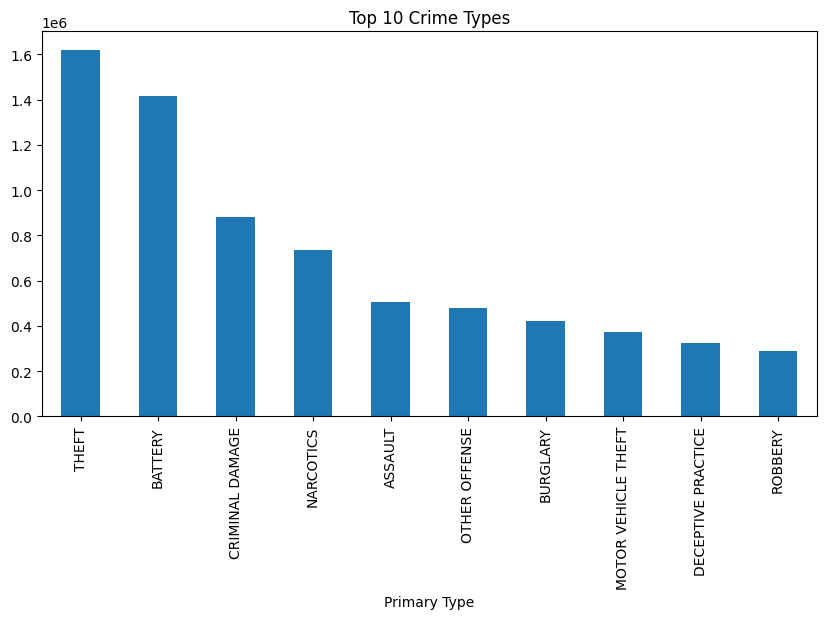

In [8]:
plt.figure(figsize=(10,5))
df['Primary Type'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.show()

### Crime Over Time

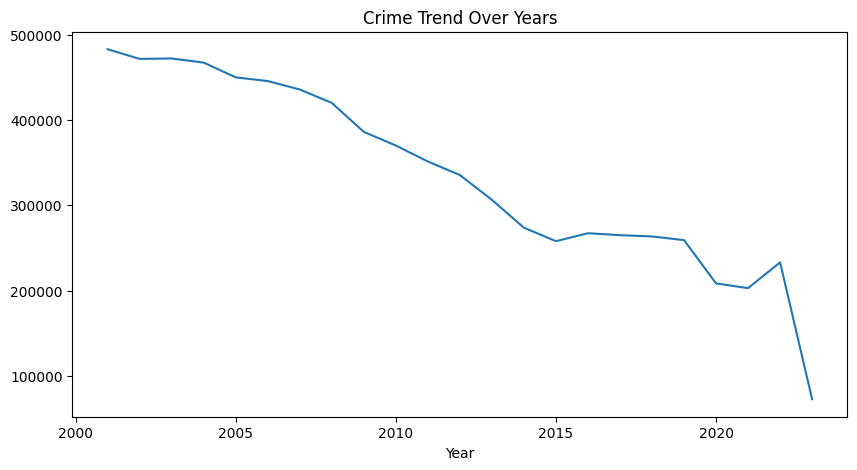

In [9]:
df.groupby('Year').size().plot(figsize=(10,5))
plt.title("Crime Trend Over Years")
plt.show()

### Crime Locations

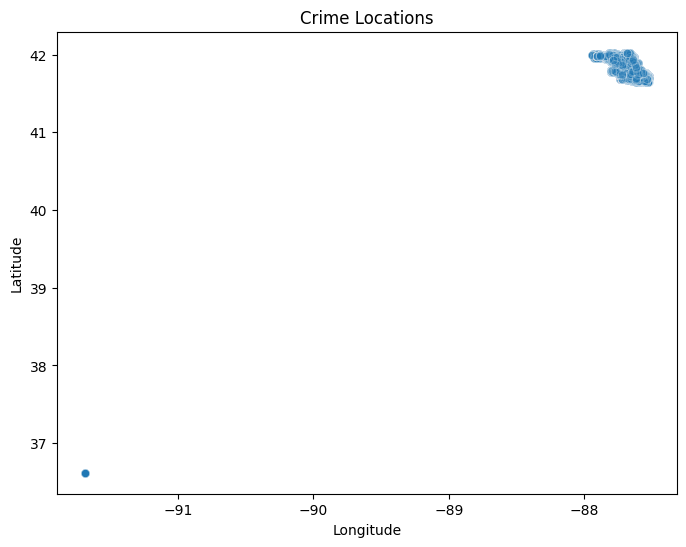

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Longitude'], y=df['Latitude'], alpha=0.3)
plt.title("Crime Locations")
plt.show()

## SECTION 7 — Crime Classification Model

In [1]:
# ==============================
# 7. CRIME CLASSIFICATION
# ==============================

le = LabelEncoder()
df['crime_label'] = le.fit_transform(df['Primary Type'])

features = ['Latitude','Longitude','Hour','Month']

X = df[features]
y = df['crime_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

NameError: name 'LabelEncoder' is not defined

## SECTION 8 — Confusion Matrix

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, pred), cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

## SECTION 9 — Crime Hotspot Detection

In [ ]:
# ==============================
# 8. HOTSPOT DETECTION
# ==============================

coords = df[['Latitude','Longitude']]

kmeans = KMeans(n_clusters=10)
df['cluster'] = kmeans.fit_predict(coords)

plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['cluster'], cmap='viridis', s=1)
plt.title("Crime Hotspots")
plt.show()

## SECTION 10 — Time Series Prediction (Basic)

In [ ]:
# ==============================
# 9. TIME SERIES
# ==============================

crime_by_day = df.groupby(df['Date'].dt.date).size()

crime_by_day.plot(figsize=(10,5))
plt.title("Daily Crime Count")
plt.show()

## SECTION 11 — Save Model

In [ ]:
# ==============================
# 10. SAVE MODEL
# ==============================

import joblib

joblib.dump(model, 'crime_model.pkl')